# Small-sized Inversions
Here, we visualize the inversions that were identified for the `small` treatment across the range of depths. The `LEVIATHAN` small, medium, and large call rates are configured to `-s 95 -m 95 -l 90`.

In [1]:
library(ggplot2)
options(warn = -1, repr.plot.width = 19, repr.plot.height = 10)
.size <- "small"

In [2]:
read_data <- function(size_treatment, depth){
    .depth <- paste("depth",depth, sep = "_")
    truthfile <- paste0("simulated_variants/inversions_genomes/", size_treatment, "/inv.", size_treatment,".vcf")
    samplesfile <- paste("simulated_data/called_sv/leviathan", size_treatment, .depth, "by_sample/inversions.bedpe", sep = "/")
    poolfile <- paste("simulated_data/called_sv/leviathan", size_treatment, .depth, "by_pop/inversions.bedpe", sep = "/")

    true_inversions <- read.table(truthfile, header = F)[,c(1,2,8)]
    true_inversions$V8 <- as.numeric(unlist(lapply(true_inversions$V8, function(X){gsub(".+END=", "", X)})))
    names(true_inversions) <- c("contig", "position_start", "position_end")
    true_inversions$sample <- "simulated_inversions"

    sample_inversions <- read.table(samplesfile, header = T)[,1:4]

    pooled_inversions <- read.table(poolfile, header = T)
    pooled_inversions <- pooled_inversions[,c("population","contig", "position_start", "position_end")]
    names(pooled_inversions)[1] <- "sample"
    if( nrow(pooled_inversions) > 0){
        pooled_inversions$sample <- paste("pooled", depth, size_treatment, sep = "_")
    }

    return(
        rbind(true_inversions, sample_inversions, pooled_inversions)
    )
}

plot_data <- function(data, size_treatment, depth){
    axis_ticks <- factor(c(paste("pooled", depth, size_treatment, sep = "_"), paste0("sample_", sprintf("%02d", 1:10)), "simulated_inversions"))
    ggplot(
        data,
        aes(
            x = position_start,
            xend = position_end,
            y = sample,
            yend = sample,
            color = sample
        )
    ) +
        scale_x_continuous(labels = scales::comma) +
        scale_y_discrete(limits = axis_ticks) +
        labs(title = "Called Inversions", subtitle = paste0("Size: ", size_treatment, " | Depth: ", depth,"X"), x = "genomic position (bp)", caption = "simulated_inversions are groundtruth") + 
        geom_segment(linewidth = 2) +
        facet_wrap(~contig, ncol = 1, scales = "free_x") +
        theme_light() +
        theme(panel.grid.major.y = element_blank(), legend.position = "None")
}

## 0.5X depth

In [3]:
depth_05X <- read_data(.size, 0.5)
tail(depth_05X)

,contig,position_start,position_end,sample
,<chr>,<int>,<dbl>,<chr>
28,2R,10569436,10578080,pooled_0.5_small
29,2R,21736721,21759356,pooled_0.5_small
30,3R,20081036,20093594,pooled_0.5_small
31,3R,22829882,22851520,pooled_0.5_small
32,3R,24971984,24984761,pooled_0.5_small
33,3R,25379866,25402914,pooled_0.5_small


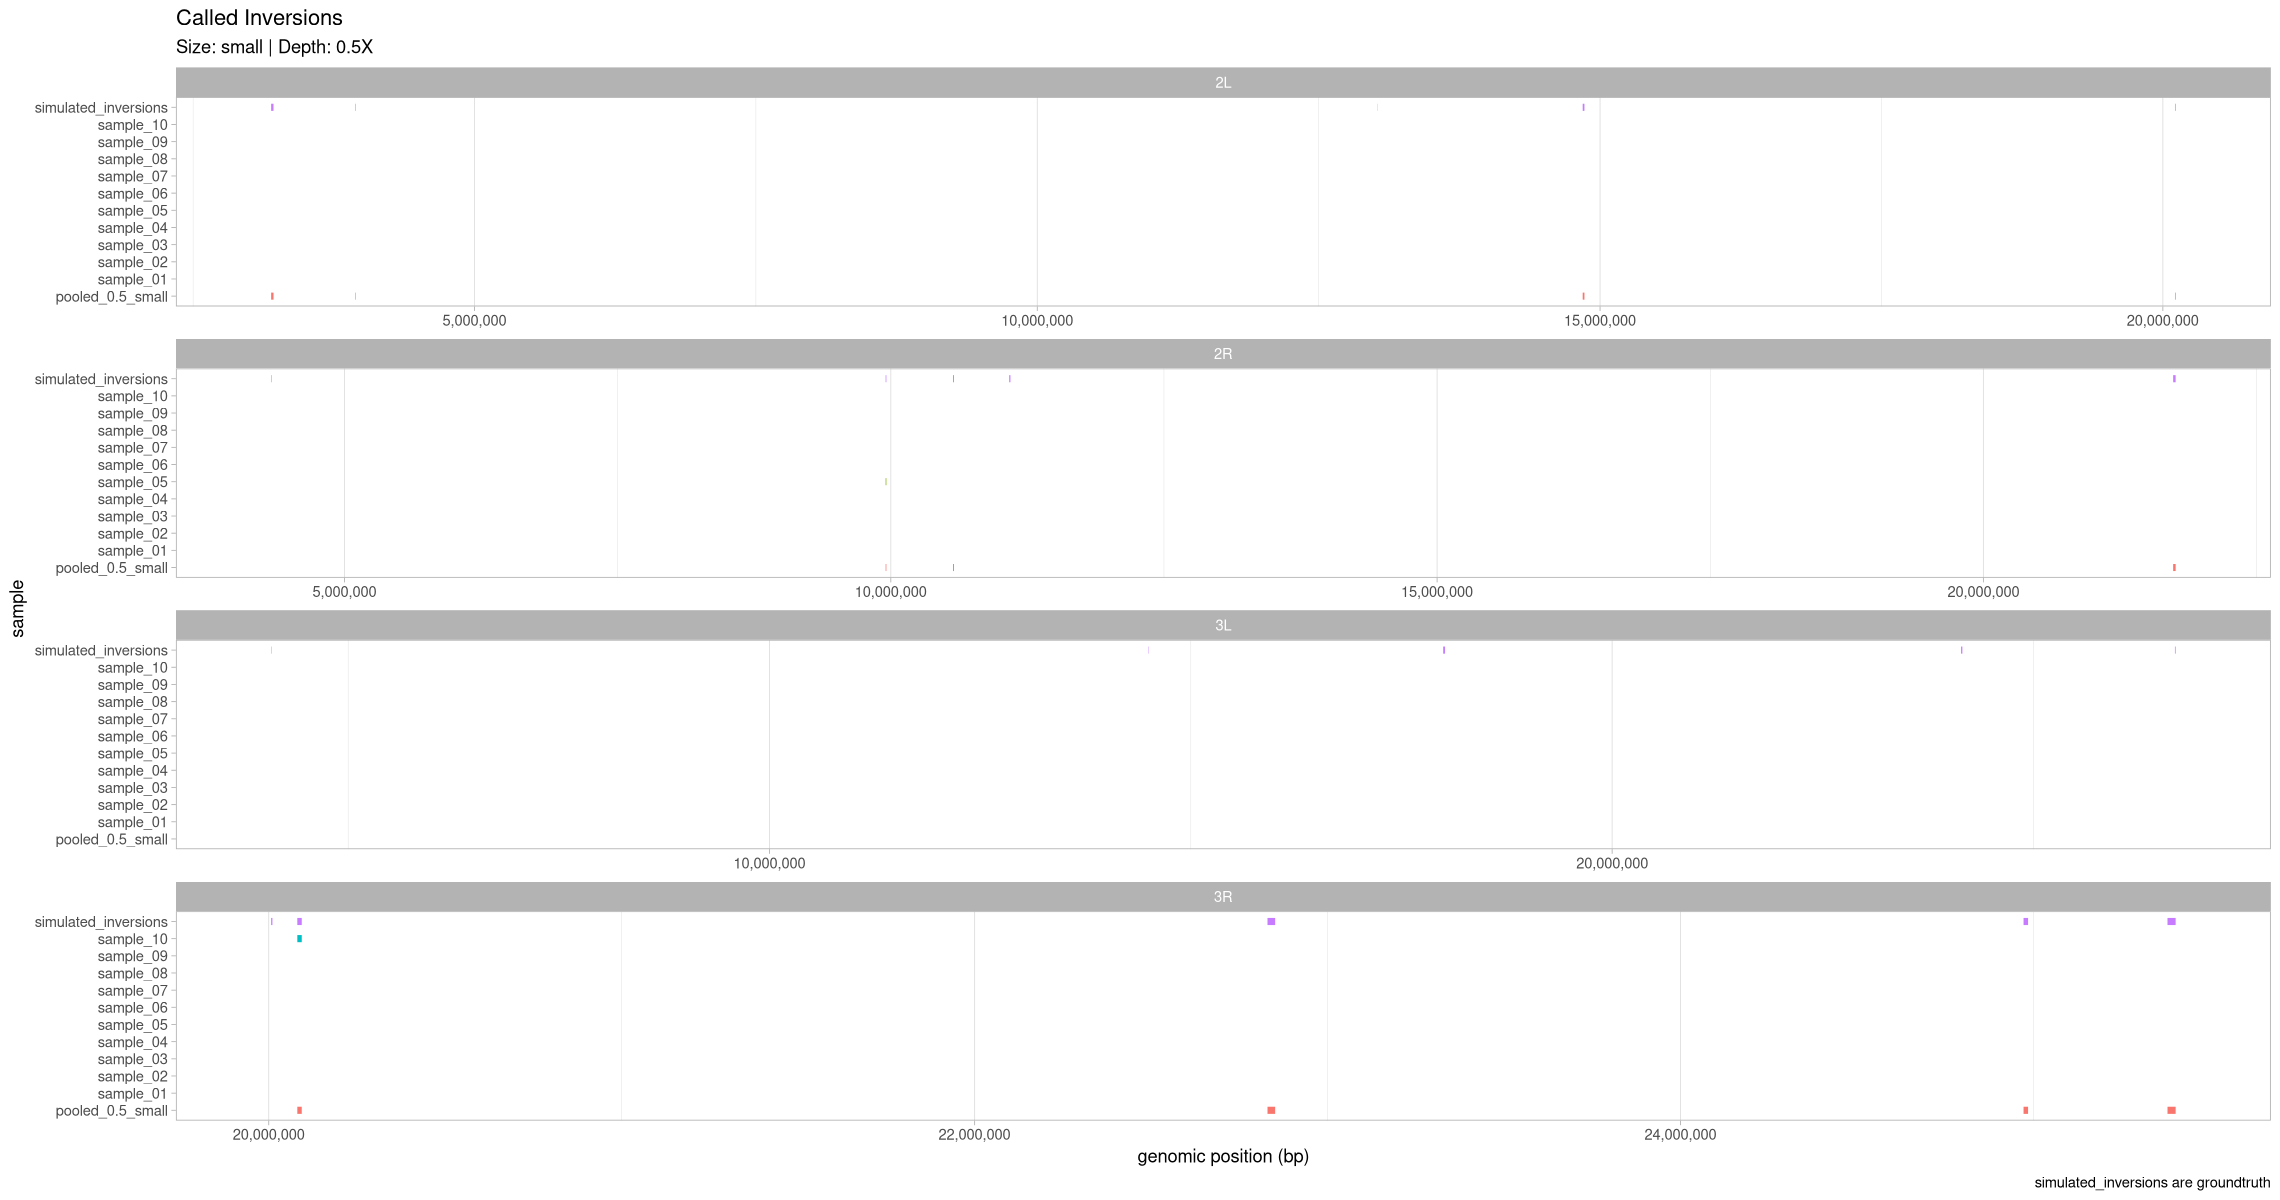

In [4]:
plot_data(depth_05X, .size, 0.5)

## 2X Depth

In [5]:
depth_2X <- read_data(.size, 2)
tail(depth_2X)

,contig,position_start,position_end,sample
,<chr>,<int>,<dbl>,<chr>
73,2R,21736721,21759354,pooled_2_small
74,3R,20006863,20010483,pooled_2_small
75,3R,20081036,20093594,pooled_2_small
76,3R,22829882,22851520,pooled_2_small
77,3R,24971984,24984761,pooled_2_small
78,3R,25379866,25402914,pooled_2_small


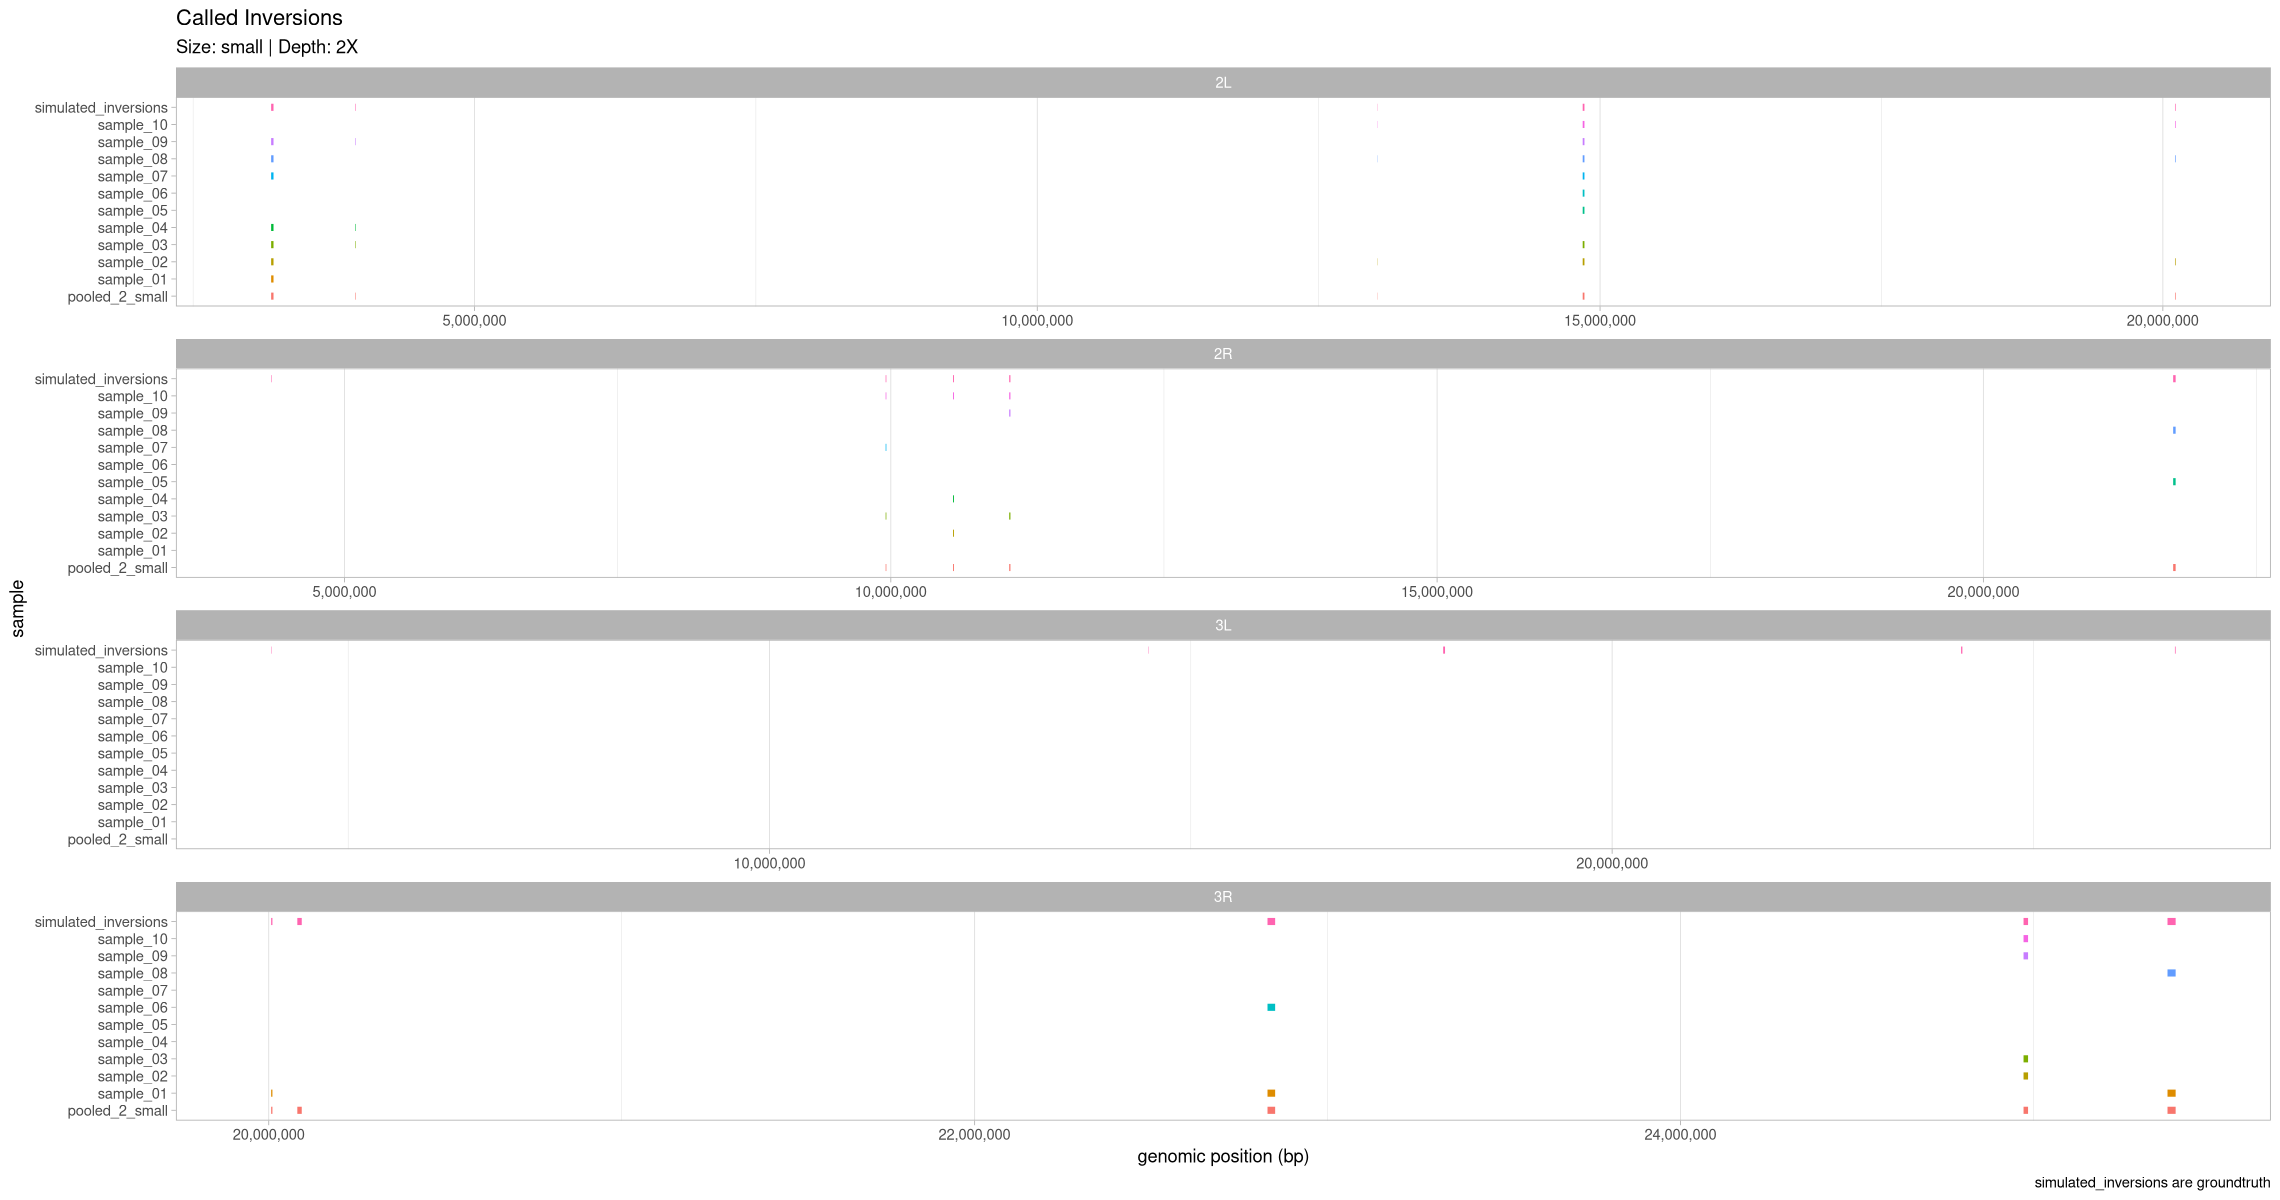

In [6]:
plot_data(depth_2X, .size, 2)

## 5X Depth

In [7]:
depth_5X <- read_data(.size, 5)
tail(depth_5X)

,contig,position_start,position_end,sample
,<chr>,<int>,<dbl>,<chr>
130,2R,21736723,21759354,pooled_5_small
131,3R,20006865,20010483,pooled_5_small
132,3R,20081036,20093594,pooled_5_small
133,3R,22829882,22851520,pooled_5_small
134,3R,24971984,24984761,pooled_5_small
135,3R,25379866,25402914,pooled_5_small


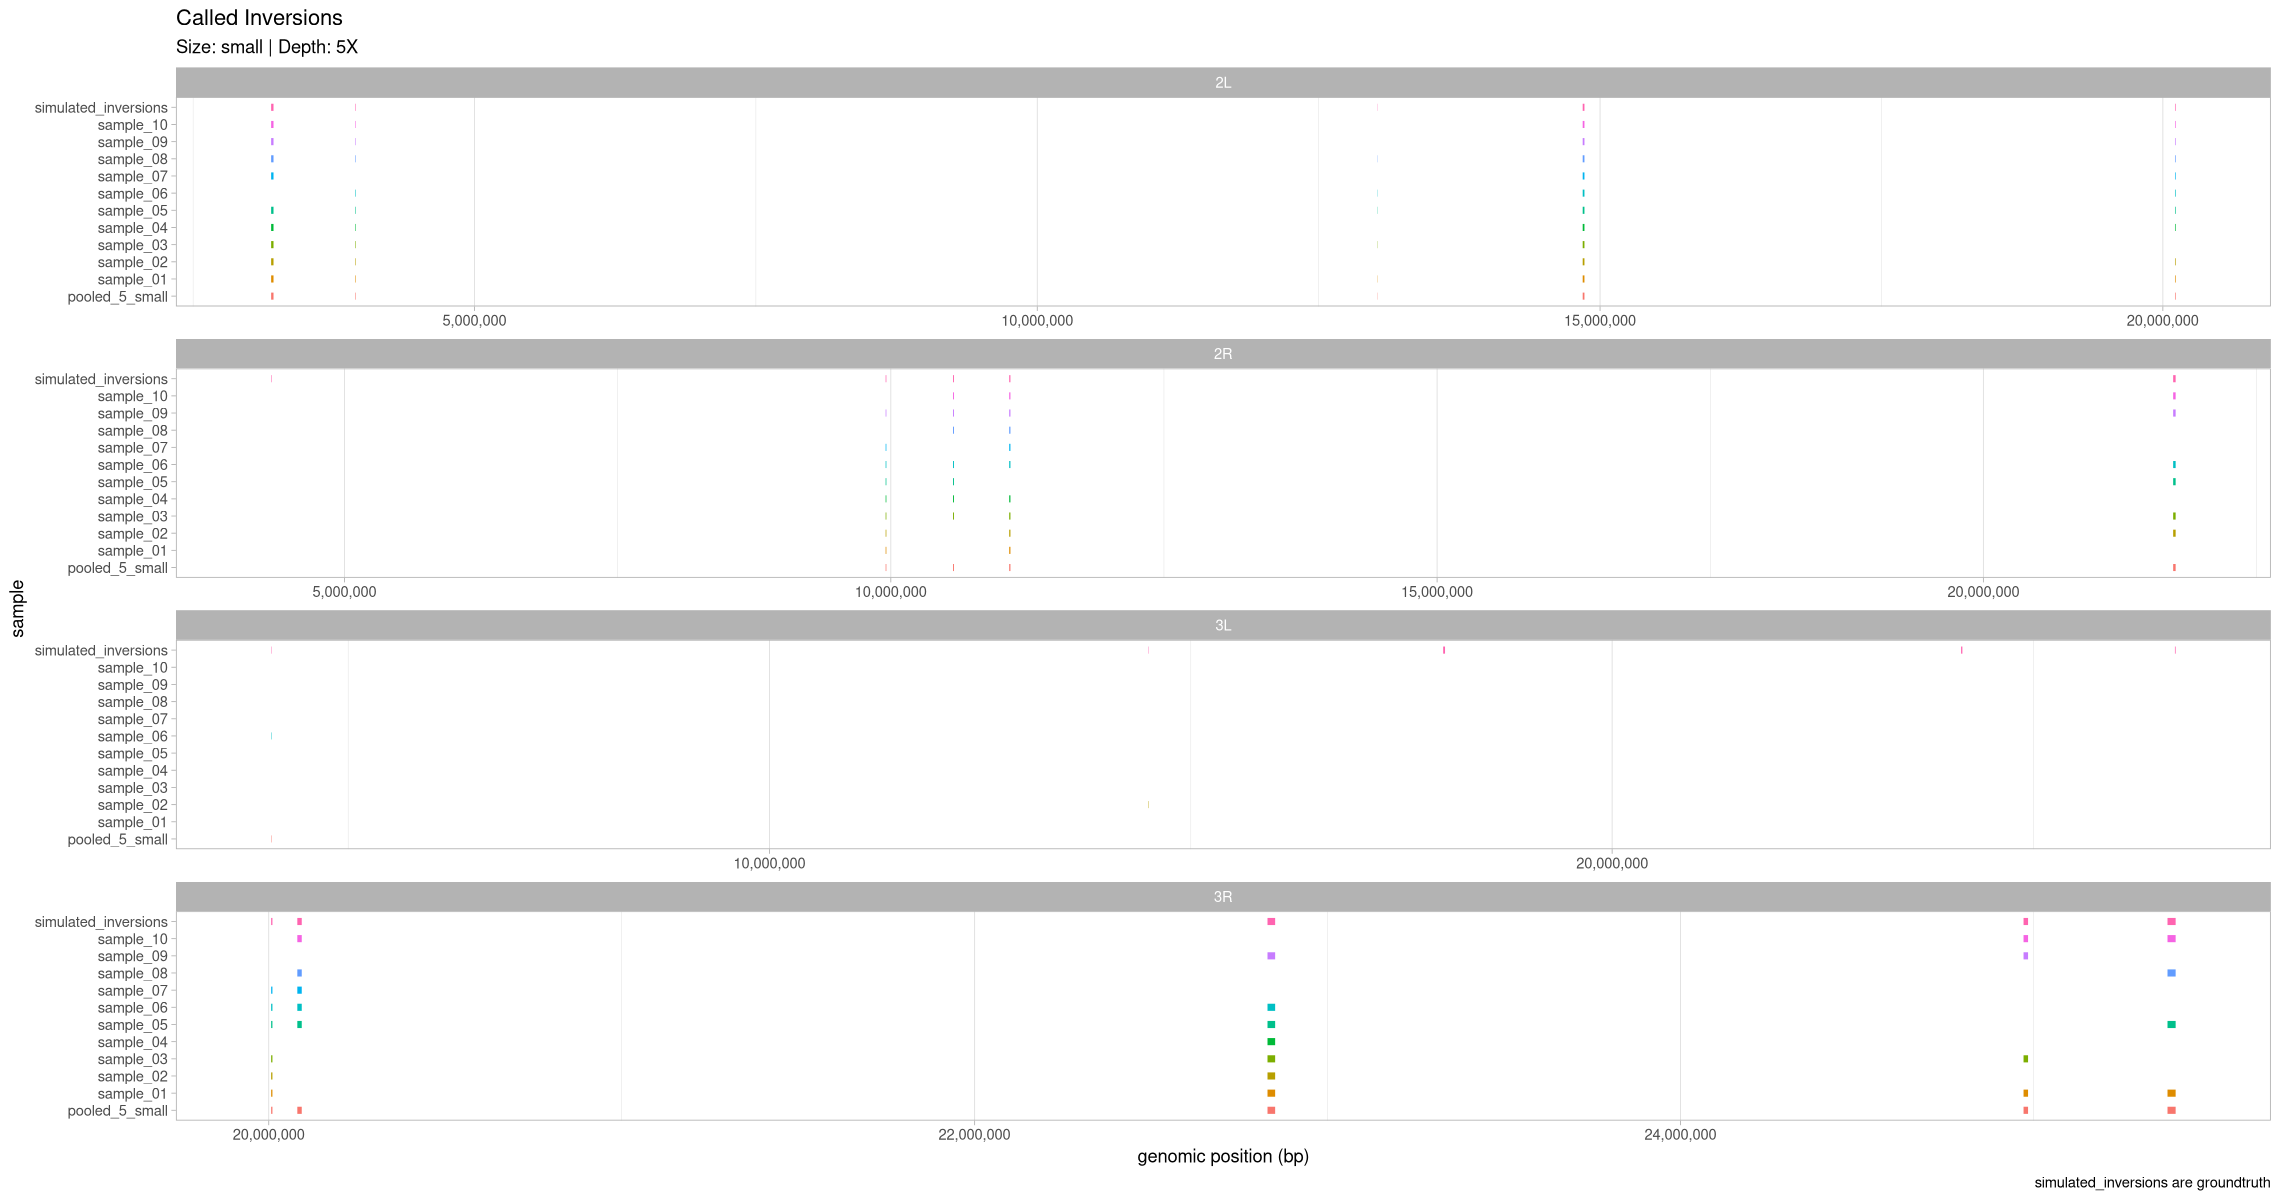

In [8]:
plot_data(depth_5X, .size, 5)

## 10X Depth

In [9]:
depth_10X <- read_data(.size, 10)
tail(depth_10X)

,contig,position_start,position_end,sample
,<chr>,<int>,<dbl>,<chr>
156,2R,21736721,21759356,pooled_10_small
157,3R,20006863,20010483,pooled_10_small
158,3R,20081036,20093594,pooled_10_small
159,3R,22829882,22851520,pooled_10_small
160,3R,24971984,24984761,pooled_10_small
161,3R,25379866,25402914,pooled_10_small


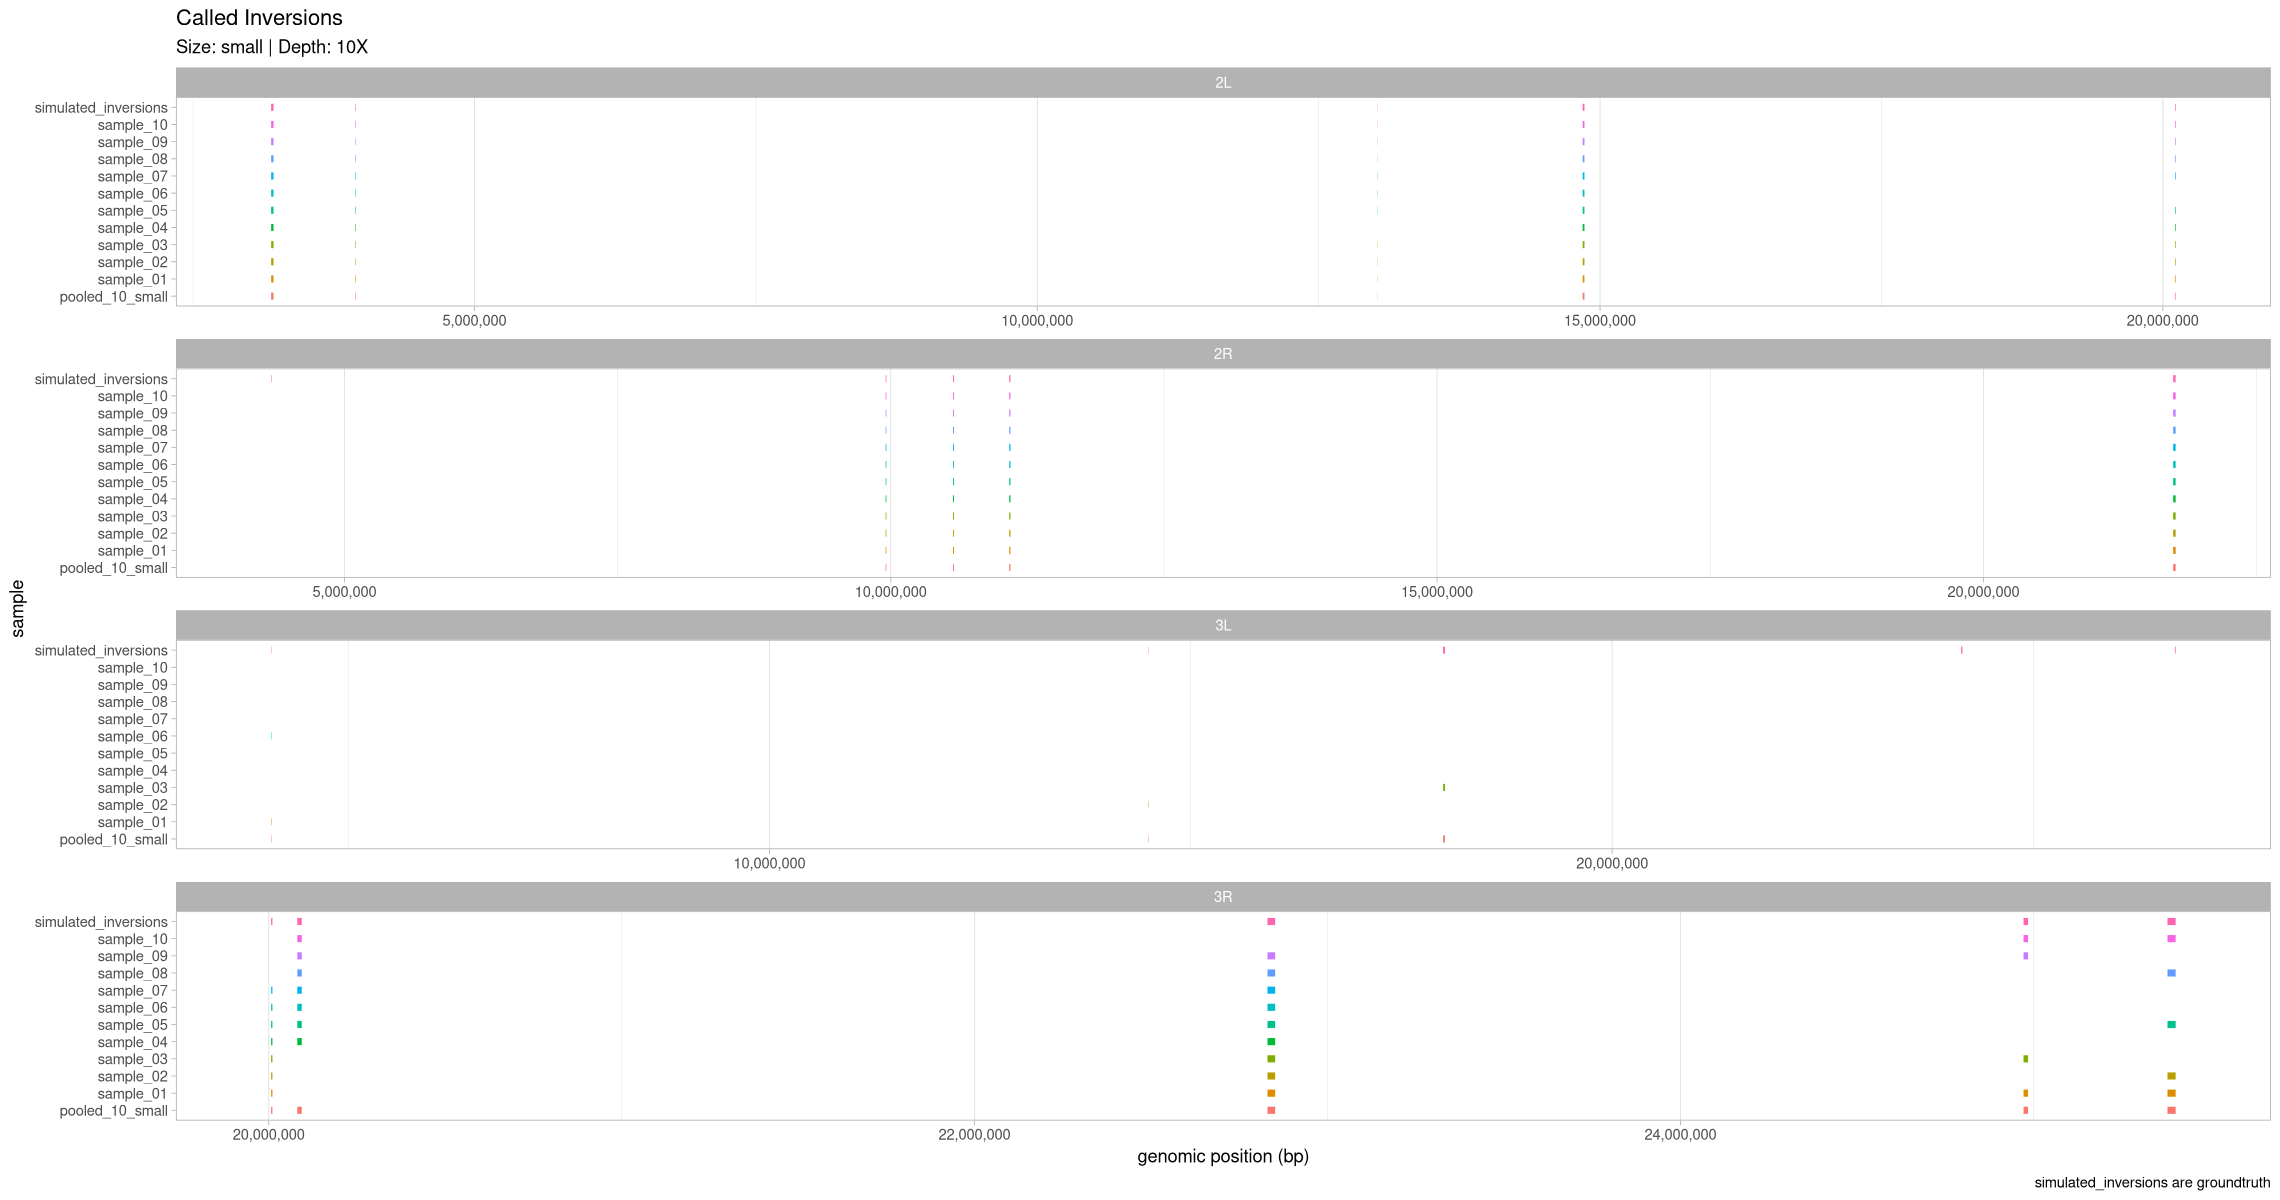

In [10]:
plot_data(depth_10X, .size, 10)

## 20X Depth

In [11]:
depth_20X <- read_data(.size, 20)
tail(depth_20X)

,contig,position_start,position_end,sample
,<chr>,<int>,<dbl>,<chr>
157,2R,21736721,21759354,pooled_20_small
158,3R,20006863,20010483,pooled_20_small
159,3R,20081036,20093594,pooled_20_small
160,3R,22829882,22851520,pooled_20_small
161,3R,24971984,24984761,pooled_20_small
162,3R,25379866,25402914,pooled_20_small


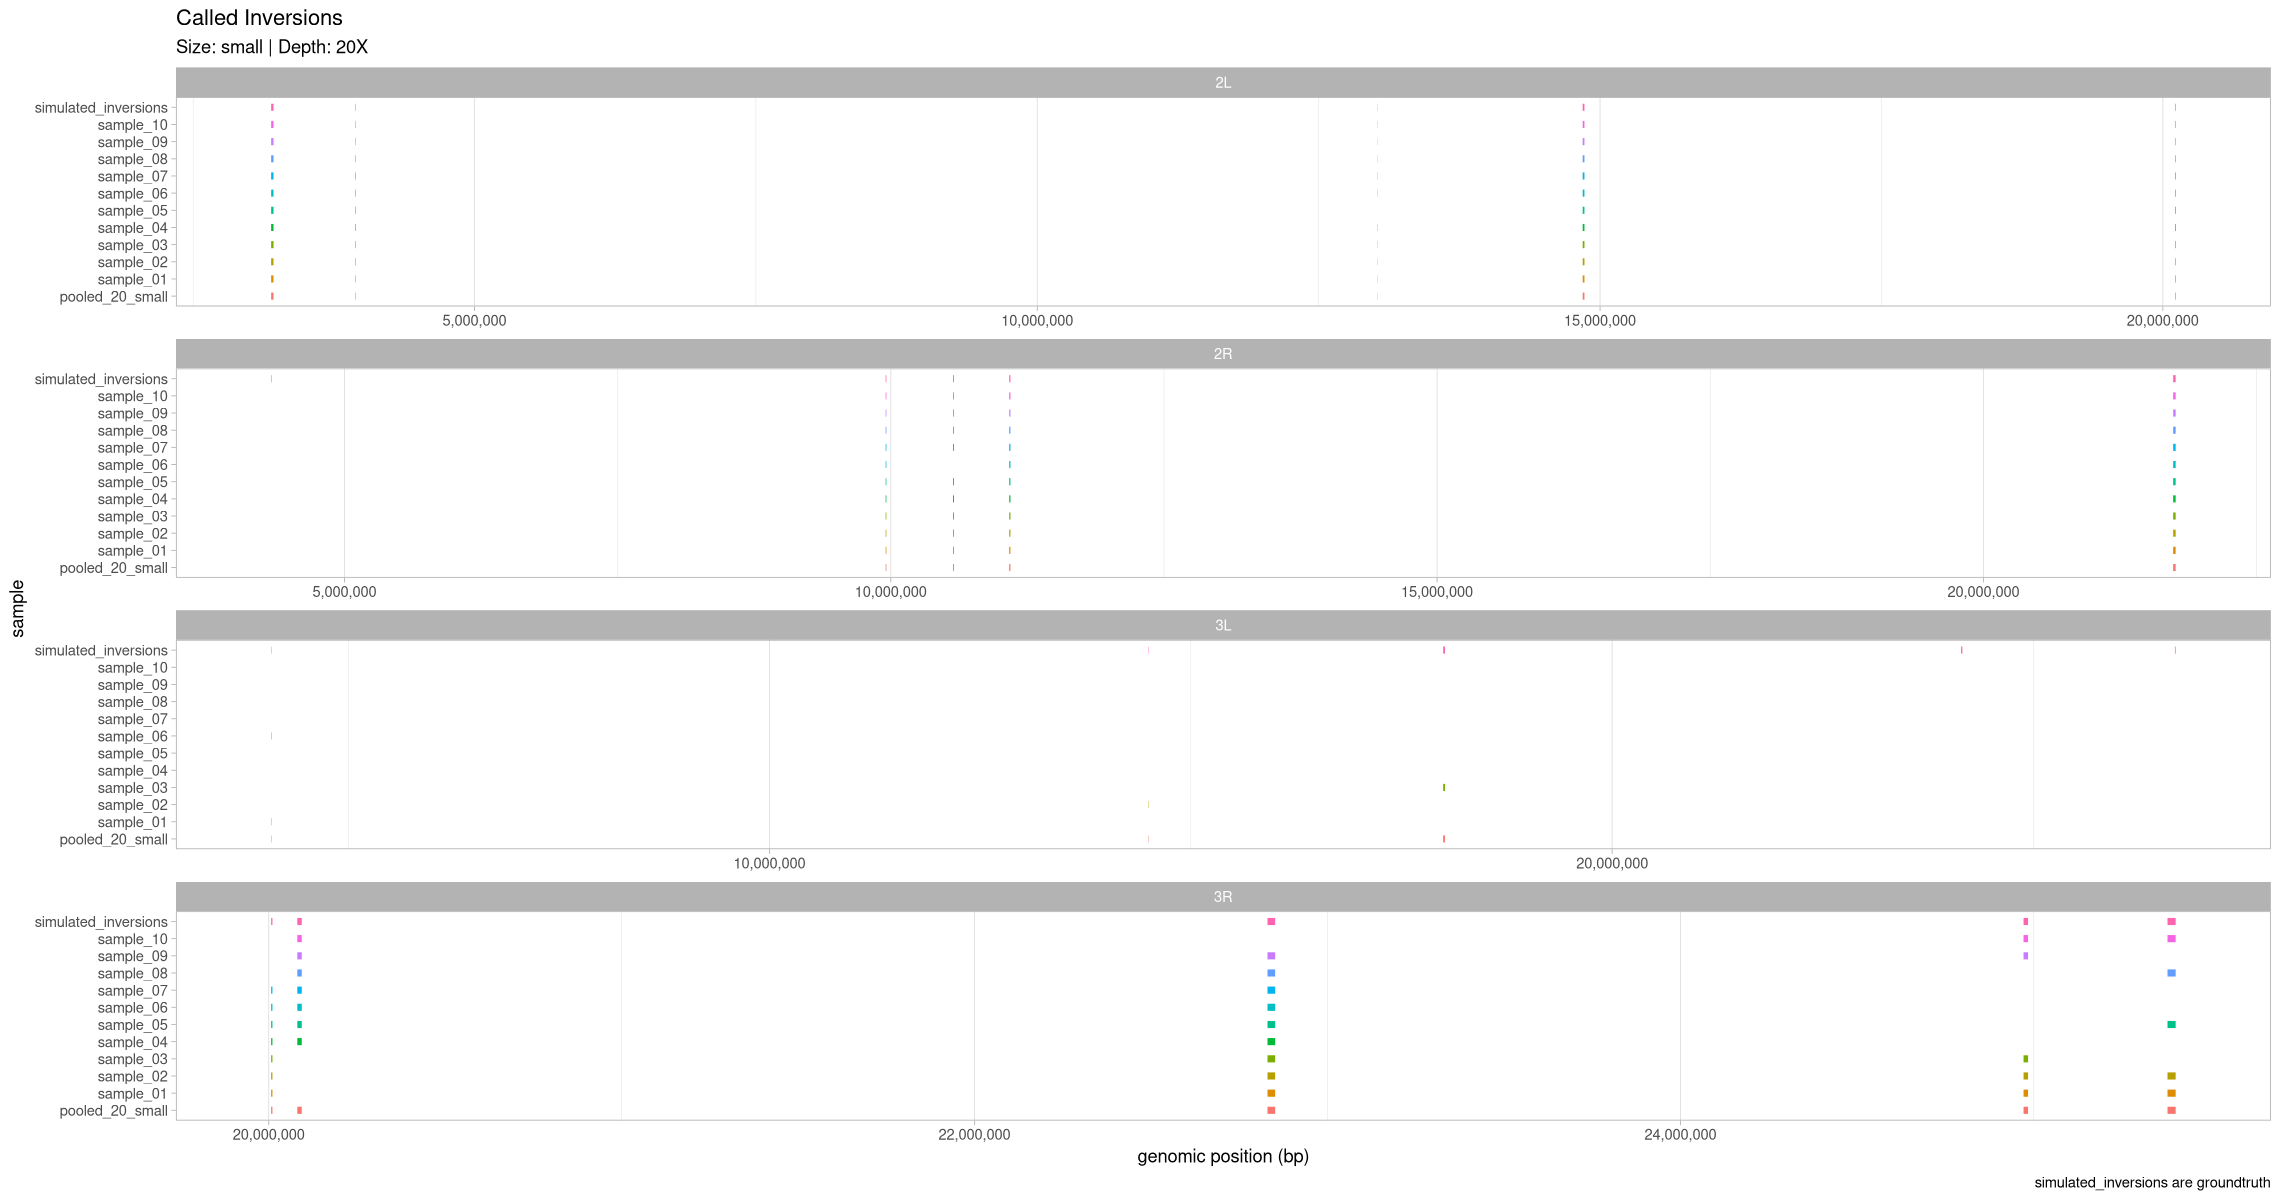

In [12]:
plot_data(depth_20X, .size, 20)